# Experiment 2 — Transformation Recovery (unknown correspondences)

**Goal:** Given point clouds $P = T_1(S)$ and $Q = T_2(S)$ **without known correspondences**,
recover the ground-truth transformation $T_{\mathrm{gt}} = T_2 \circ T_1^{-1}$ using ICP
(EM with nearest-neighbor E-step and SVD Procrustes M-step).

In [12]:
import sys
sys.path.insert(0, '../src')

import matplotlib.pyplot as plt
import numpy as np

from icp import ICP, ICPResult, fit_multi_seed, MultiSeedSyntheticICPResult
from synthetic import SyntheticExperiment
from utils import get_error_metrics
from visualization import PointCloudVisualizer, ErrorMetricsVisualizer
from tabulate import tabulate

plt.style.use("seaborn-v0_8-whitegrid")

N_SEEDS = 30

## 1. Synthetic data generation

Same setup as Experiment 1:
- $S$: random irregular point cloud
- $T_1, T_2$: random rigid transformations with small per-point Gaussian noise
- $P = T_1(S)$, $Q = T_2(S)$ — **matching is unknown**

The ground-truth $T_{\mathrm{gt}} = T_2 \circ T_1^{-1}$ exists mathematically but is **not used during fitting** — ICP only sees $P$ and $Q$. We compute it here solely to evaluate the recovered result.

In [13]:
exp = SyntheticExperiment.generate(n=2000, noise_std=0, t_scale=10.0, seed=42)
print(exp)

╭──────────────────────┬──────────────────────────────────────────────╮
│ Original Point Cloud │ PointCloud(n=2000)                           │
│ Transformation 1     │ RigidTransformation(rot=149.5°, t_norm=6.46) │
│ Transformation 2     │ RigidTransformation(rot=153.1°, t_norm=7.34) │
│ Point Cloud 1        │ PointCloud(n=2000)                           │
│ Point Cloud 2        │ PointCloud(n=2000)                           │
│ GT transformation    │ RigidTransformation(rot=16.3°, t_norm=11.22) │
╰──────────────────────┴──────────────────────────────────────────────╯


## 2. Run ICP

EM loop:
- **E-step:** nearest-neighbor matching (KD-tree)
- **M-step:** SVD Procrustes fit on matched pairs
- **Convergence:** $\|R_{\mathrm{step}} - I\|_F + \|t_{\mathrm{step}}\| < \varepsilon$ (Small transformation this step)

In [14]:
icp = ICP(max_iter=400, tol=1e-10, verbose=True)
result: ICPResult = icp.fit(exp.P, exp.Q)

print(result)

ICP converged:   8%|▊         | 31/400 [00:00<00:01, 187.67it/s, residual=0.0000]

╭────────────┬──────────────────────────────────────────────╮
│ Converged  │ True                                         │
│ Iterations │ 32                                           │
│ Recovered  │ RigidTransformation(rot=16.3°, t_norm=11.22) │
╰────────────┴──────────────────────────────────────────────╯


# Error metrics & Convergence
Since we run the ICP algorithm on a synthetic problem we know the ground truth transformation to recover. Three basic error metrics:
1. **Rotation error vs ground truth**: How much do the final transformation and the ground truth transformation differ in angle (deg)
2. **Translation error vs ground truth**: How much do the final transformation and the ground truth transformation differ in translation direction and distance
3. **Mean Residuals**: The mean distance to the closest point across all points in the cloud.

The error vs ground truth is what we want to have minimized. The mean residuals is the quantity that ICP actually tries to minimize. It may achieve low residual errors while having large deviations from the ground truth for experiments with lots of local optima.

A final convergence criteria are the delta values. ICP is terminated when $delta < tol$. Delta describes the difference between the identity and the composition of the last 10 step transformations. If in the last 10 steps no significant addition to the total transformation was found the algorithm terminates.

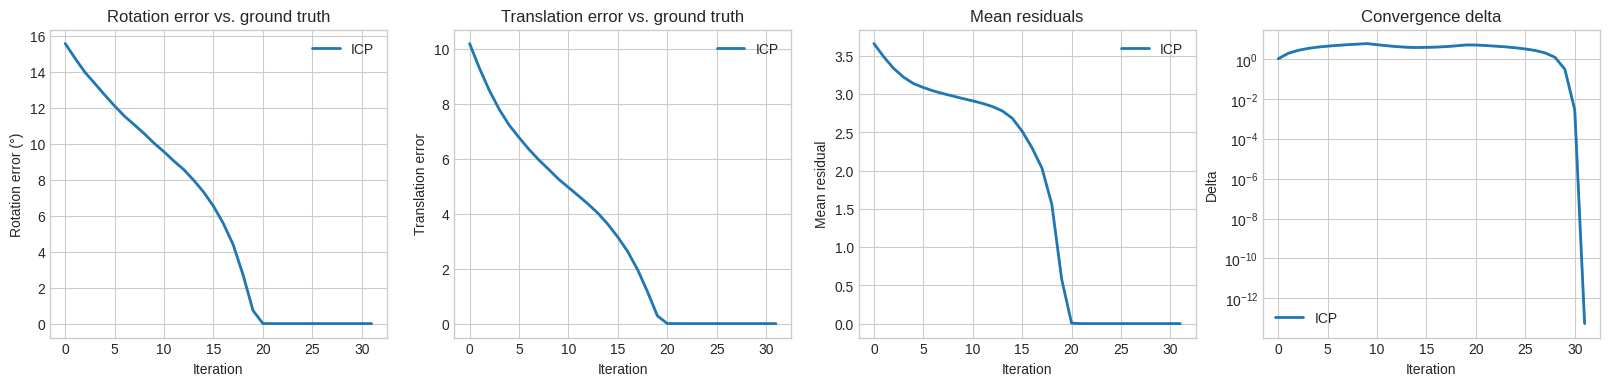

╭─────────────────────┬─────────╮
│ Metric              │ Value   │
├─────────────────────┼─────────┤
│ Rotation error      │ 0.0000° │
│ Translation error   │ 0.0000  │
│ Mean point residual │ 0.0000  │
│ Mean point residual │ 0.0000  │
╰─────────────────────┴─────────╯


In [15]:
ErrorMetricsVisualizer.plot_convergence([[result]], [[exp.T_gt]], ["ICP"])
plt.show()

rotation_error, translation_error, residuals = get_error_metrics(result.transformation, exp.T_gt, exp.P, exp.Q)

rows = [
    ["Rotation error",      f"{rotation_error:.4f}°"],
    ["Translation error",   f"{translation_error:.4f}"],
    ["Mean point residual", f"{residuals.mean():.4f}"],
    ["Mean point residual", f"{residuals.max():.4f}"],
]
print(tabulate(rows, headers=["Metric", "Value"], tablefmt="rounded_outline"))

## 4. Alignment snapshots

Source cloud (blue) vs. target cloud (red) at selected iterations, projected onto XY.
Shows how the cloud physically moves into alignment over the EM iterations.

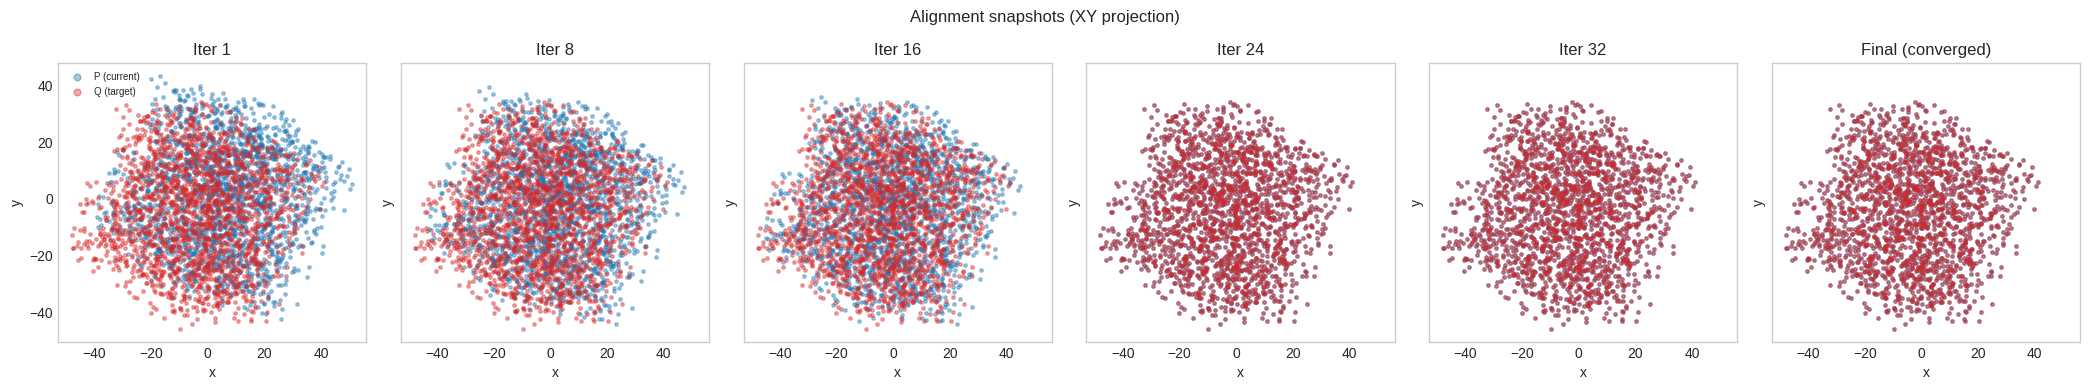

In [16]:
n_iters = result.n_iterations
num_snapshots = 5
snap_iters = np.linspace(0, n_iters - 1, num_snapshots, dtype=int)
final_cloud = result.transformation.apply(exp.P)

fig, axes = plt.subplots(1, len(snap_iters) + 1, figsize=(3.5 * (len(snap_iters) + 1), 3.5), sharey=True, sharex=True)
PointCloudVisualizer.plot_alignment_snapshots(axes, result.cloud_history, exp.Q, final_cloud, snap_iters)

plt.suptitle('Alignment snapshots (XY projection)', y=1.02)
plt.tight_layout()
plt.savefig('../results/2_icp_alignment.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Multi-seed evaluation

Run ICP on N different random seeds (same hyperparameters) and summarize rotation error, translation error, and max residual across runs as boxplots.

In [17]:
seeds = list(range(N_SEEDS))
experiment_kwargs: dict[str, int | float] = {
    "n": 2000,
    "noise_std": 0,
    "t_scale": 8.0,
}
multi_seed_results: MultiSeedSyntheticICPResult = fit_multi_seed(icp, seeds, experiment_kwargs=experiment_kwargs)

Solving 30 seeds: 100%|██████████| 30/30 [00:12<00:00,  2.44it/s]


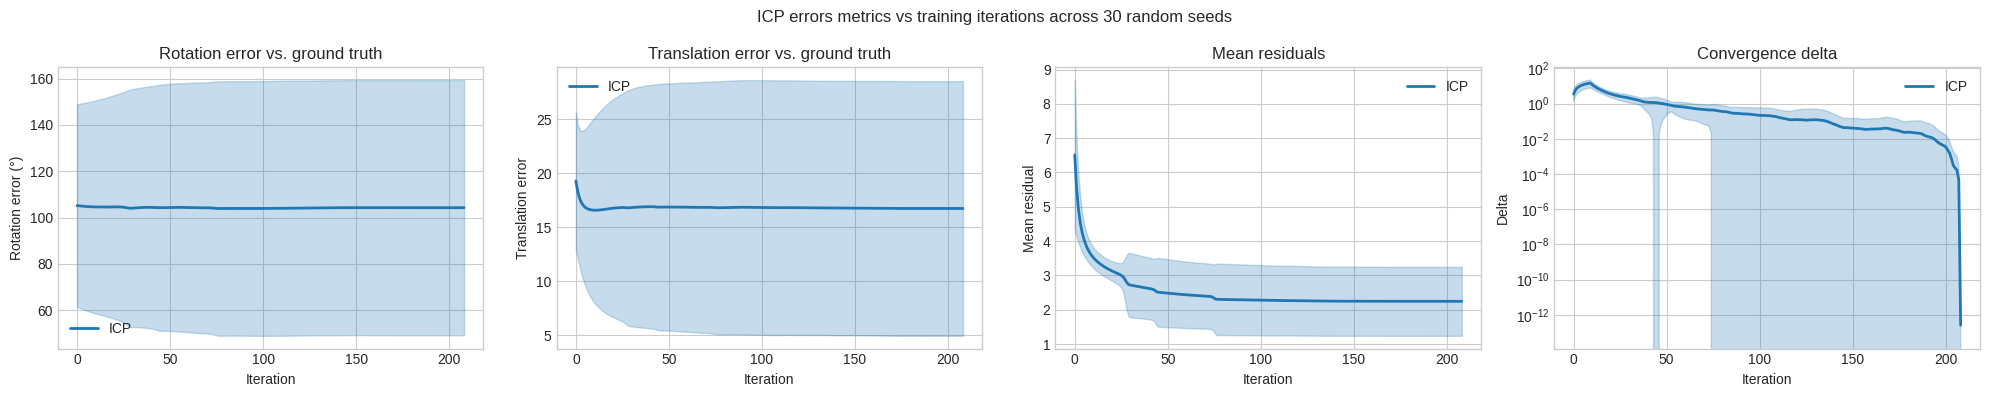

In [18]:
ErrorMetricsVisualizer.plot_convergence([multi_seed_results.results], [multi_seed_results.ground_truths], ["ICP"])
plt.suptitle(f'ICP errors metrics vs training iterations across {N_SEEDS} random seeds')
plt.tight_layout()
plt.savefig('../results/2_icp_performance_vs_iterations_across_seeds.png', dpi=150, bbox_inches='tight')
plt.show()

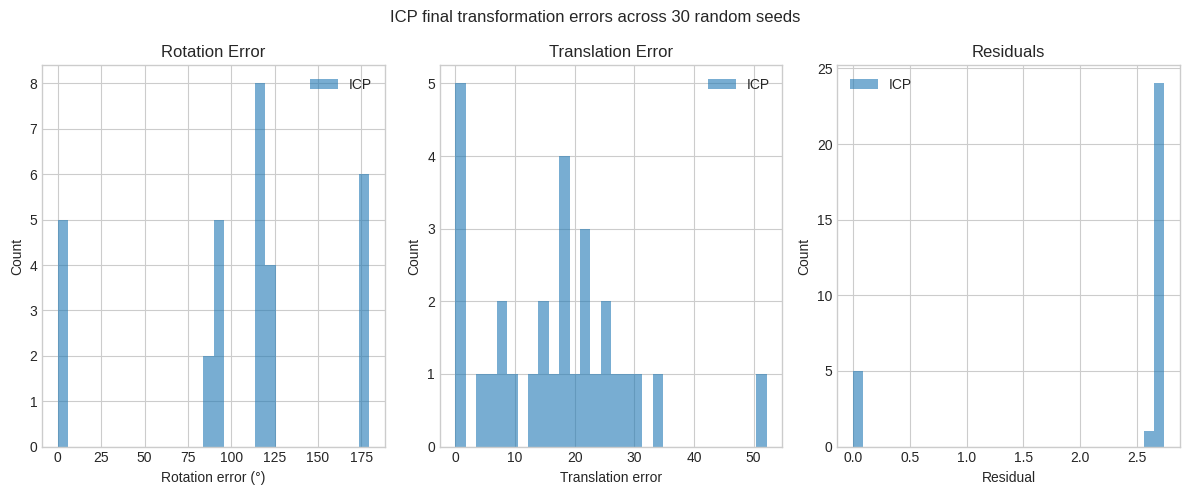

In [20]:
ErrorMetricsVisualizer.plot_hists_over_seeds(
    rot_errors_per_method=[multi_seed_results.rotation_errors],
    translation_errors_per_method=[multi_seed_results.translation_errors],
    residuals_per_method=[multi_seed_results.mean_residuals],
    method_labels=['ICP'],
)
plt.suptitle(f'ICP final transformation errors across {N_SEEDS} random seeds')
plt.tight_layout()
plt.savefig('../results/2_icp_performance_across_seeds.png', dpi=150, bbox_inches='tight')
plt.show()